# News Classification - NLP Pipeline

## Projet de Classification d'Articles d'Actualité

Ce notebook implémente une pipeline NLP complète pour classifier automatiquement les articles d'actualité en 4 catégories :
- **World** (0) : Actualités mondiales
- **Sports** (1) : Sports
- **Business** (2) : Affaires et économie
- **Sci/Tech** (3) : Science et technologie

### Étapes du pipeline :
1. Chargement des données depuis Hugging Face (SetFit/ag_news)
2. Conversion en DataFrame pandas
3. Analyse exploratoire des données (EDA)
4. Prétraitement des textes
5. Génération des embeddings avec Sentence Transformers

In [4]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

from datasets import load_dataset
from sentence_transformers import SentenceTransformer

sns.set(style='whitegrid')
print("✅ Imports OK")

✅ Imports OK


## 1. Chargement des Données depuis Hugging Face

Nous utilisons le dataset **SetFit/ag_news** qui contient des articles d'actualité classés en 4 catégories.

In [5]:
# 1. Charger le dataset depuis HuggingFace
dataset = load_dataset("SetFit/ag_news")
print(f" Dataset chargé: {dataset}")

 Dataset chargé: DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7600
    })
})


## 2. Conversion en DataFrame Pandas

In [6]:
# 2. Convertir en DataFrame pandas
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])
df = pd.concat([df_train, df_test], ignore_index=True)

# Ajouter les noms de catégories
label_mapping = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
df['category'] = df['label'].map(label_mapping)

print(f"✅ Train: {len(df_train)} | Test: {len(df_test)} | Total: {len(df)}")
df.head()

✅ Train: 120000 | Test: 7600 | Total: 127600


,text,label,label_text,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business,Business
4,"Oil prices soar to all-time record, posing new...",2,Business,Business


## 3. Analyse Exploratoire des Données (EDA)

### 3.1 Informations générales sur le dataset

In [7]:
# 3.1 Infos générales
print(f"Colonnes: {df.columns.tolist()}")
print(f"Valeurs manquantes: {df.isnull().sum().sum()}")
print(f"Doublons: {df.duplicated(subset=['text']).sum()}")

Colonnes: ['text', 'label', 'label_text', 'category']
Valeurs manquantes: 0
Doublons: 0


### 3.2 Distribution des catégories

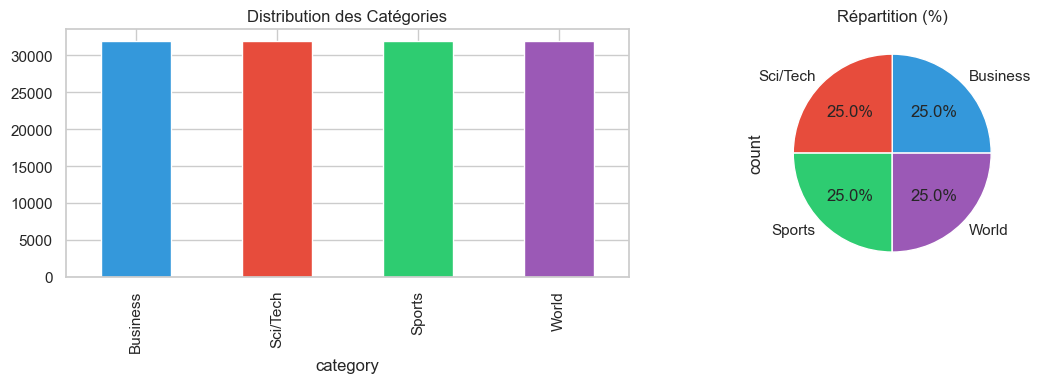

In [8]:
# 3.2 Distribution des catégories
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

df['category'].value_counts().plot(kind='bar', ax=ax[0], color=colors)
ax[0].set_title('Distribution des Catégories')

df['category'].value_counts().plot(kind='pie', ax=ax[1], colors=colors, autopct='%1.1f%%')
ax[1].set_title('Répartition (%)')
plt.tight_layout()
plt.show()

### 3.3 Analyse de la longueur des textes

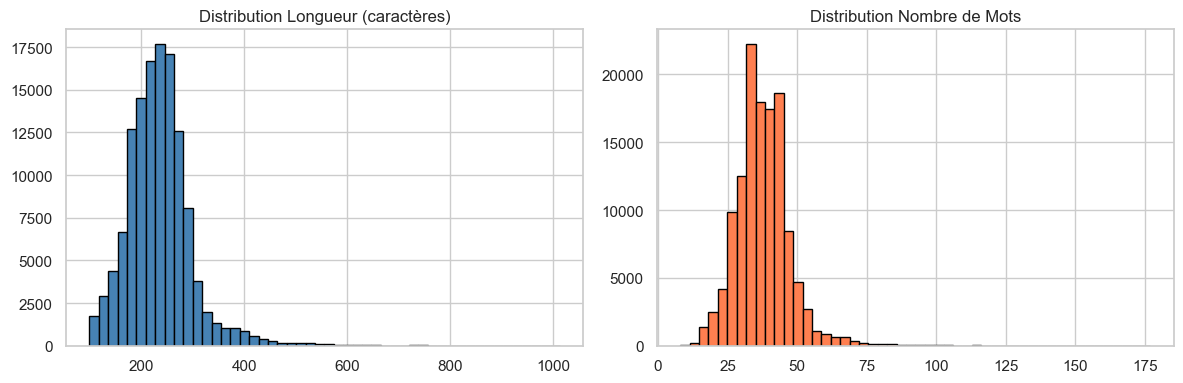

Moyenne: 38 mots par article


In [9]:
# 3.3 Longueur des textes
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='black')
ax[0].set_title('Distribution Longueur (caractères)')
ax[1].hist(df['word_count'], bins=50, color='coral', edgecolor='black')
ax[1].set_title('Distribution Nombre de Mots')
plt.tight_layout()
plt.show()

print(f"Moyenne: {df['word_count'].mean():.0f} mots par article")

### 3.4 Analyse des mots les plus fréquents

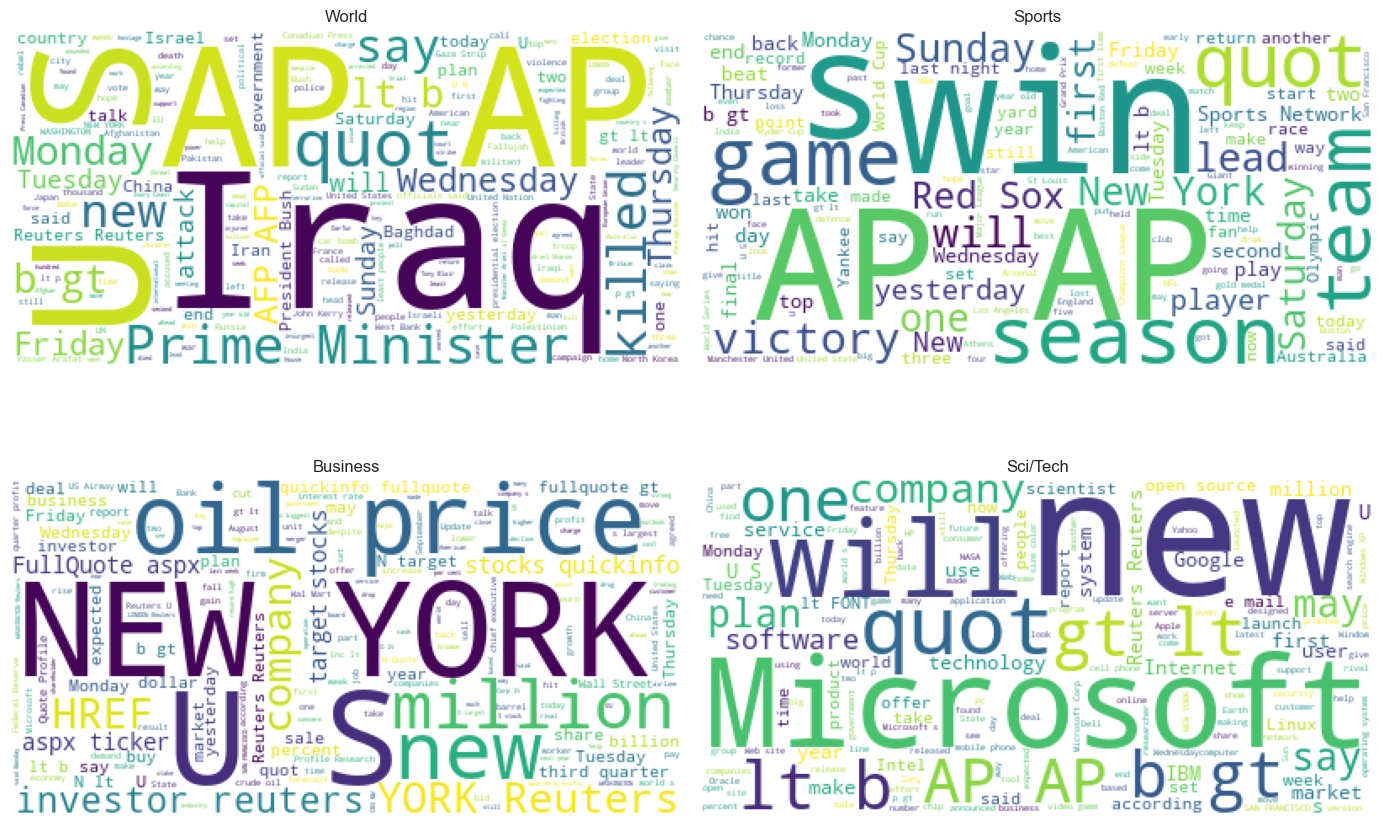

In [10]:
# 3.4 WordCloud par catégorie
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, (label, cat) in enumerate(label_mapping.items()):
    text = ' '.join(df[df['label'] == label]['text'])
    wc = WordCloud(width=400, height=200, background_color='white').generate(text)
    axes[idx//2, idx%2].imshow(wc)
    axes[idx//2, idx%2].set_title(cat)
    axes[idx//2, idx%2].axis('off')
plt.tight_layout()
plt.show()

In [25]:
import re 
op = re.sub(r"https?//","<token>","https// jbckjebckq")
print(op)




<token> jbckjebckq


## 4. Prétraitement

**Minimal preprocessing pour Sentence Transformers:**
- ✅ Supprimer doublons
- ✅ Nettoyer espaces
- ❌ PAS de suppression stopwords (le modèle en a besoin!)

In [11]:
# 4.1 Fonction de prétraitement minimal
def preprocess_text(text):
    """Nettoie uniquement les espaces - garde tout le contenu sémantique."""
    if not isinstance(text, str):
        return ""
    return re.sub(r'\s+', ' ', text).strip()

# Exemple
print(f"Avant: 'This   is   NOT   good!'")
print(f"Après: '{preprocess_text('This   is   NOT   good!')}'")
print("→ On garde 'NOT' car il change le sens!")

Avant: 'This   is   NOT   good!'
Après: 'This is NOT good!'
→ On garde 'NOT' car il change le sens!


In [12]:
# 4.2 Appliquer le prétraitement
df_clean = df.drop_duplicates(subset=['text']).copy()
df_clean['text_clean'] = df_clean['text'].apply(preprocess_text)
print(f"✅ {len(df)} → {len(df_clean)} articles (doublons supprimés)")

✅ 127600 → 127600 articles (doublons supprimés)


## 5. Génération des Embeddings

**Modèle:** `paraphrase-multilingual-MiniLM-L12-v2` → vecteurs 384D

In [13]:
# 5.1 Charger le modèle d'embeddings
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print(f"✅ Modèle chargé: {model.get_sentence_embedding_dimension()}D")

✅ Modèle chargé: 384D


In [14]:
# Batch processing to handle large datasets
batch_size = 1000
embeddings = []

for i in range(0, len(df_clean), batch_size):
    batch_texts = df_clean['text_clean'].iloc[i:i+batch_size].tolist()
    batch_embeddings = model.encode(batch_texts, show_progress_bar=True)
    embeddings.append(batch_embeddings)

# Combine all batches into a single array
embeddings = np.vstack(embeddings)
print(f"✅ Embeddings generated for the entire dataset: {embeddings.shape}")

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

✅ Embeddings generated for the entire dataset: (127600, 384)


In [15]:
# 5.3 Visualisation t-SNE (384D → 2D)
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
colors = {'World': '#3498db', 'Sports': '#e74c3c', 'Business': '#2ecc71', 'Sci/Tech': '#9b59b6'}
for cat, color in colors.items():
    mask = categories == cat
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=color, label=cat, alpha=0.6)
plt.legend()
plt.title('t-SNE des Embeddings par Catégorie')
plt.show()

NameError: name 'categories' is not defined

<Figure size 1000x700 with 0 Axes>

## 6. Stockage ChromaDB

Base de données vectorielle pour recherche par similarité.

In [ ]:
# 6.1 Stocker dans ChromaDB
import chromadb

chroma_path = '../data/chromadb'
os.makedirs(chroma_path, exist_ok=True)
client = chromadb.PersistentClient(path=chroma_path)

# Créer collection
try: client.delete_collection("news_embeddings")
except: pass
collection = client.create_collection("news_embeddings", metadata={"hnsw:space": "cosine"})

# Ajouter les données
collection.add(
    ids=[f"article_{i}" for i in range(len(embeddings))],
    embeddings=embeddings.tolist(),
    documents=df_sample['text_clean'].tolist(),
    metadatas=[{"label": int(labels[i]), "category": categories[i]} for i in range(len(labels))]
)
print(f"✅ {collection.count()} embeddings stockés dans ChromaDB")

✅ 1000 embeddings stockés dans ChromaDB


In [ ]:
# 6.2 Test: recherche d'articles similaires
query_embedding = embeddings[0].tolist()
results = collection.query(query_embeddings=[query_embedding], n_results=3)

print(f"🔍 Articles similaires à: '{df_sample['text_clean'].iloc[0][:50]}...'")
for i, (doc, meta) in enumerate(zip(results['documents'][0], results['metadatas'][0])):
    print(f"   {i+1}. [{meta['category']}] {doc[:60]}...")

🔍 Articles similaires à: 'No. 3 Georgia Tech 79, Arkansas-Little Rock 54 Geo...'
   1. [Sports] No. 3 Georgia Tech 79, Arkansas-Little Rock 54 Georgia Tech ...
   2. [Sports] College Basketball: Georgia Tech Strolls to Win ATLANTA (Spo...
   3. [Sports] Carter #39;s #39;got nothing to say #39; after scoring 15 Af...


## 7. Entraînement ML

**Modèles:** Logistic Regression & SVM (les meilleurs pour embeddings)

In [ ]:
# 7.1 Entraînement des modèles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import joblib

# Split
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# Entraîner (probability=True pour avoir predict_proba)
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'SVM': SVC(kernel='rbf', probability=True)  # probability=True requis pour Streamlit
}

for name, m in models.items():
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"{name}: {acc:.2%}")

# Choisir le meilleur
best_name = max(models, key=lambda n: accuracy_score(y_test, models[n].predict(X_test)))
best_model = models[best_name]
print(f"\n🏆 Meilleur: {best_name}")

LogisticRegression: 80.50%
SVM: 85.50%

🏆 Meilleur: SVM


In [ ]:
# 7.2 Évaluation + Overfitting check
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

# Overfitting?
train_acc = accuracy_score(y_train, best_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
print(f"Train: {train_acc:.2%} | Test: {test_acc:.2%} | Gap: {train_acc-test_acc:.2%}")
print("✅ OK" if (train_acc - test_acc) < 0.05 else "⚠️ Overfitting")

              precision    recall  f1-score   support

       World       0.86      0.82      0.84        44
      Sports       0.96      0.94      0.95        53
    Business       0.78      0.84      0.81        50
    Sci/Tech       0.83      0.81      0.82        53

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.86       200

Train: 99.12% | Test: 85.50% | Gap: 13.62%
⚠️ Overfitting
Train: 99.12% | Test: 85.50% | Gap: 13.62%
⚠️ Overfitting


In [ ]:
# 7.3 Sauvegarder le modèle
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/best_classifier.joblib')
print("✅ Modèle sauvegardé → Prêt pour Streamlit!")

✅ Modèle sauvegardé → Prêt pour Streamlit!
